<a href="https://colab.research.google.com/github/carlavilla/DataManagement/blob/main/CV_DMPS0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

##Set Up

In [1]:
import time, os, sys, re
import zipfile, json, datetime, string
#from pprint import pprint -can be used to limit width of data display. Doesn't seem necessary here.
import numpy as np
from statistics import *

import matplotlib.pyplot as plt

import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler
#s4 = Styler(df4, uuid_len=0, cell_ids=False)

import missingno as msno

from google.colab import files

import seaborn as sns

from google.colab import data_table
data_table.enable_dataframe_formatter()
data_table.max_columns = 50
#!and may have to click at top right spreadsheet icon

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#MAGICS and THEMES/STYLES: important! does affect not just shading/colors, but also fonts, spacing, etc
#(even if you only select default (v not selecting anything) [but does seem to work better if you do make explicit sleections])

###magics: https://ipython.readthedocs.io/en/stable/interactive/magics.html
#most essential setup for vis: it does affect vis! careful!! stick with inline, maybe notebook; others mostly for non-notebook, eg spyder environ
#https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html recomends *inline*!
#show current one:
#%matplotlib
#%matplotlib --list
#interactive plots:
#%matplotlib notebook
#static images of your plot:
%matplotlib inline
#may play with this one and other magics (btw default is probably agg)
#%matplotlib nbagg
##https://www.marktechpost.com/2023/10/20/6-magic-commands-for-jupyter-notebooks-in-python-data-science/
#%%latex
#%ai
#%run
#%writefile
#%history -n

###themes/styles: https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
#https://jakevdp.github.io/PythonDataScienceHandbook/04.11-settings-and-stylesheets.html
#https://matplotlib.org/stable/tutorials/introductory/customizing.html
#here more about art and style than under the hood functionality as with magics, explore and experiment
#many may find 'default' or seaborn ones more pleasing; my fav 'classic' is back from 90s ;)
#plt.style.available #list available styles :) may install more
#plt.style.use('default') # more delicate subtle than classic
plt.style.use('classic')  #  'seaborn-whitegrid' 'seaborn-white' 'seaborn-poster'
# btw: magics v theme/style sequence matters, eg if i specify classic style before inline magic, i wouldnt get grey bounding box im getting

#sometimes have to install library which you get from https://pypi.org/
#!pip install geopandas

#Bot Identification on the Internet

##The Problem
*   Malicious bots have been a persistent problem in online public forums over the last decade. By masquerading as humans, bots contribute to misinformation by influencing public opinion and confounding the interpretation of online data ([Ferrara et al., 2016](https://cacm.acm.org/research/the-rise-of-social-bots/))
*   Methods to identify bot data tend to rely on access to extensive metadata, knowledge of user behavior and data patterns, and platform-dependent features. These requirements complicate the fast determination of bot presence and the development of models that function across contexts ([Yang et al., 2020](https://doi.org/10.1609/aaai.v34i01.5460)).

##A Solution
* [Yang et al., 2020](https://doi.org/10.1609/aaai.v34i01.5460) gathered known human and bot Twitter accounts from 2015 to 2019 across a variety of interests. They tested several machine learning models to identify the most predictive features for human-bot determination.
* The best fit model identified 20 features that predicted the likelihood of a user being a bot or human when tested across multiple subsets of the original full dataset.

![20 Identifying Features](https://raw.githubusercontent.com/carlavilla/DataManagement/main/top20.png)

[Image display code source](https://stackoverflow.com/questions/61704041/how-may-i-insert-an-image-from-my-github-repository-in-my-google-colab-notebook)

SHAP scores determined the likelihood of a bot, with negative scores being more human-like and positive scores more bot-like. Red indicates upper values within the range of the feature (e.g. count, ratio, etc) while blue indicates lower values. A higher concentration of a color on one side suggests a higher likelihood for a human or bot to follow that trend value. For instance, there is more red on the human-like side for favourites-count and followers_count, suggesting that humans tend to have more favourited accounts and followers than bots. Humans also tend to be verified more than bots. In contrast, we see that bots tend to have a higher friends_growth_rate and friends_count.

#Current study
For the next couple assignments, I will be using a random subset of the data from Yang et al., 2020 and examining the accuracy at which these 20 features predict the presence of bots at a dataset and case level.

##Bots dataset

In [ ]:
! ls

sample_data


In [8]:
! wget -q -O botwiki-2019_tweets.json https://raw.githubusercontent.com/carlavilla/DataManagement/main/botwiki-2019_tweets.json
with open('botwiki-2019_tweets.json', 'r') as file:
    bots_raw = json.load(file)
# The original code loaded 'bots' as a list. To use .info(), it needs to be a pandas DataFrame.
#bots = pd.read_json('botwiki-2019_tweets.json')
# bots.head(7) # Uncomment this line if you want to see the head of the DataFrame after loading

In [5]:
bots_raw = pd.read_json('botwiki-2019_tweets.json')
bots_raw.head(5)

,created_at,user
0,2019-06-05 21:43:20+00:00,"{'id': 969398693249126400, 'id_str': '96939869..."
1,2019-04-02 13:26:02+00:00,"{'id': 2402022649, 'id_str': '2402022649', 'na..."
2,2019-06-05 20:22:03+00:00,"{'id': 2976541239, 'id_str': '2976541239', 'na..."
3,2019-06-05 18:56:21+00:00,"{'id': 4425828741, 'id_str': '4425828741', 'na..."
4,2019-06-05 20:54:02+00:00,"{'id': 817082622824169472, 'id_str': '81708262..."


In [9]:
bots_raw[0]
bots_raw[0]['user'] #['id']

bots = pd.json_normalize(bots_raw)
bots.head(2)

{'created_at': 'Wed Jun 05 21:43:20 +0000 2019',
 'user': {'id': 969398693249126400,
  'id_str': '969398693249126400',
  'name': 'Random Goth Lyric Generator',
  'screen_name': 'goth_lyrics',
  'location': 'City of Dis',
  'description': 'Esoteric dark verse from aeons before twitter crept out of its unholy sepulchre.',
  'url': 'https://t.co/s9UkVMDACm',
  'entities': {'url': {'urls': [{'url': 'https://t.co/s9UkVMDACm',
      'expanded_url': 'https://osric.com/rglg/',
      'display_url': 'osric.com/rglg/',
      'indices': [0, 23]}]},
   'description': {'urls': []}},
  'protected': False,
  'followers_count': 23,
  'friends_count': 8,
  'listed_count': 1,
  'created_at': 'Fri Mar 02 02:27:13 +0000 2018',
  'favourites_count': 2,
  'utc_offset': None,
  'time_zone': None,
  'geo_enabled': False,
  'verified': False,
  'statuses_count': 3792,
  'lang': None,
  'contributors_enabled': False,
  'is_translator': False,
  'is_translation_enabled': False,
  'profile_background_color': '0000

{'id': 969398693249126400,
 'id_str': '969398693249126400',
 'name': 'Random Goth Lyric Generator',
 'screen_name': 'goth_lyrics',
 'location': 'City of Dis',
 'description': 'Esoteric dark verse from aeons before twitter crept out of its unholy sepulchre.',
 'url': 'https://t.co/s9UkVMDACm',
 'entities': {'url': {'urls': [{'url': 'https://t.co/s9UkVMDACm',
     'expanded_url': 'https://osric.com/rglg/',
     'display_url': 'osric.com/rglg/',
     'indices': [0, 23]}]},
  'description': {'urls': []}},
 'protected': False,
 'followers_count': 23,
 'friends_count': 8,
 'listed_count': 1,
 'created_at': 'Fri Mar 02 02:27:13 +0000 2018',
 'favourites_count': 2,
 'utc_offset': None,
 'time_zone': None,
 'geo_enabled': False,
 'verified': False,
 'statuses_count': 3792,
 'lang': None,
 'contributors_enabled': False,
 'is_translator': False,
 'is_translation_enabled': False,
 'profile_background_color': '000000',
 'profile_background_image_url': 'http://abs.twimg.com/images/themes/theme1/bg.p

,created_at,user.id,user.id_str,user.name,user.screen_name,user.location,user.description,user.url,user.entities.url.urls,user.entities.description.urls,...,user.profile_sidebar_fill_color,user.profile_text_color,user.profile_use_background_image,user.has_extended_profile,user.default_profile,user.default_profile_image,user.following,user.follow_request_sent,user.notifications,user.translator_type
0,Wed Jun 05 21:43:20 +0000 2019,969398693249126400,969398693249126400,Random Goth Lyric Generator,goth_lyrics,City of Dis,Esoteric dark verse from aeons before twitter ...,https://t.co/s9UkVMDACm,"[{'url': 'https://t.co/s9UkVMDACm', 'expanded_...",[],...,000000,000000,False,True,False,False,False,False,False,none
1,Tue Apr 02 13:26:02 +0000 2019,2402022649,2402022649,Transiting Now,transitingnow,Earth,Demonstrating the vast number of transiting ex...,https://t.co/L8ARV5JWBz,"[{'url': 'https://t.co/L8ARV5JWBz', 'expanded_...",[],...,EFEFEF,333333,True,False,False,False,False,False,False,none


In [ ]:
bots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   created_at                               698 non-null    object
 1   user.id                                  698 non-null    int64 
 2   user.id_str                              698 non-null    object
 3   user.name                                698 non-null    object
 4   user.screen_name                         698 non-null    object
 5   user.location                            698 non-null    object
 6   user.description                         698 non-null    object
 7   user.url                                 382 non-null    object
 8   user.entities.url.urls                   382 non-null    object
 9   user.entities.description.urls           698 non-null    object
 10  user.protected                           698 non-null    bool 

In [ ]:
bots.head(5)

,created_at,user.id,id_str,user.name,user.screen_name,user.location,user.description,user.url,user.entities.url.urls,user.entities.description.urls,...,user.profile_sidebar_fill_color,user.profile_text_color,user.profile_use_background_image,user.has_extended_profile,user.default_profile,user.default_profile_image,user.following,user.follow_request_sent,user.notifications,user.translator_type
0,Wed Jun 05 21:43:20 +0000 2019,969398693249126400,969398693249126400,Random Goth Lyric Generator,goth_lyrics,City of Dis,Esoteric dark verse from aeons before twitter ...,https://t.co/s9UkVMDACm,"[{'url': 'https://t.co/s9UkVMDACm', 'expanded_...",[],...,000000,000000,False,True,False,False,False,False,False,none
1,Tue Apr 02 13:26:02 +0000 2019,2402022649,2402022649,Transiting Now,transitingnow,Earth,Demonstrating the vast number of transiting ex...,https://t.co/L8ARV5JWBz,"[{'url': 'https://t.co/L8ARV5JWBz', 'expanded_...",[],...,EFEFEF,333333,True,False,False,False,False,False,False,none
2,Wed Jun 05 20:22:03 +0000 2019,2976541239,2976541239,TheRiddlerBot,TheRiddlerBot,"Coimbra, Portugal",Solve the riddle by replying only the name of ...,https://t.co/1v8BON9QpT,"[{'url': 'https://t.co/1v8BON9QpT', 'expanded_...",[],...,DDEEF6,333333,True,False,True,False,False,False,False,none
3,Wed Jun 05 18:56:21 +0000 2019,4425828741,4425828741,🌊🌊🌊🌊🌊🌊🌊🌊🌊,tiny_seas,sui.sexy,✨🌊 by @suisea ✨ donate: https://t.co/MS5qM3a8B...,https://t.co/Q6hC8oOXfQ,"[{'url': 'https://t.co/Q6hC8oOXfQ', 'expanded_...","[{'url': 'https://t.co/MS5qM3a8Bl', 'expanded_...",...,DDEEF6,333333,True,False,True,False,False,False,False,none
4,Wed Jun 05 20:54:02 +0000 2019,817082622824169472,817082622824169472,Wordfindatron,wordfindatron,The Grid,I make little word-find puzzles. Bot by @joshl...,https://t.co/Dn62jWBqAe,"[{'url': 'https://t.co/Dn62jWBqAe', 'expanded_...",[],...,000000,000000,False,False,False,False,False,False,False,none


<Axes: >

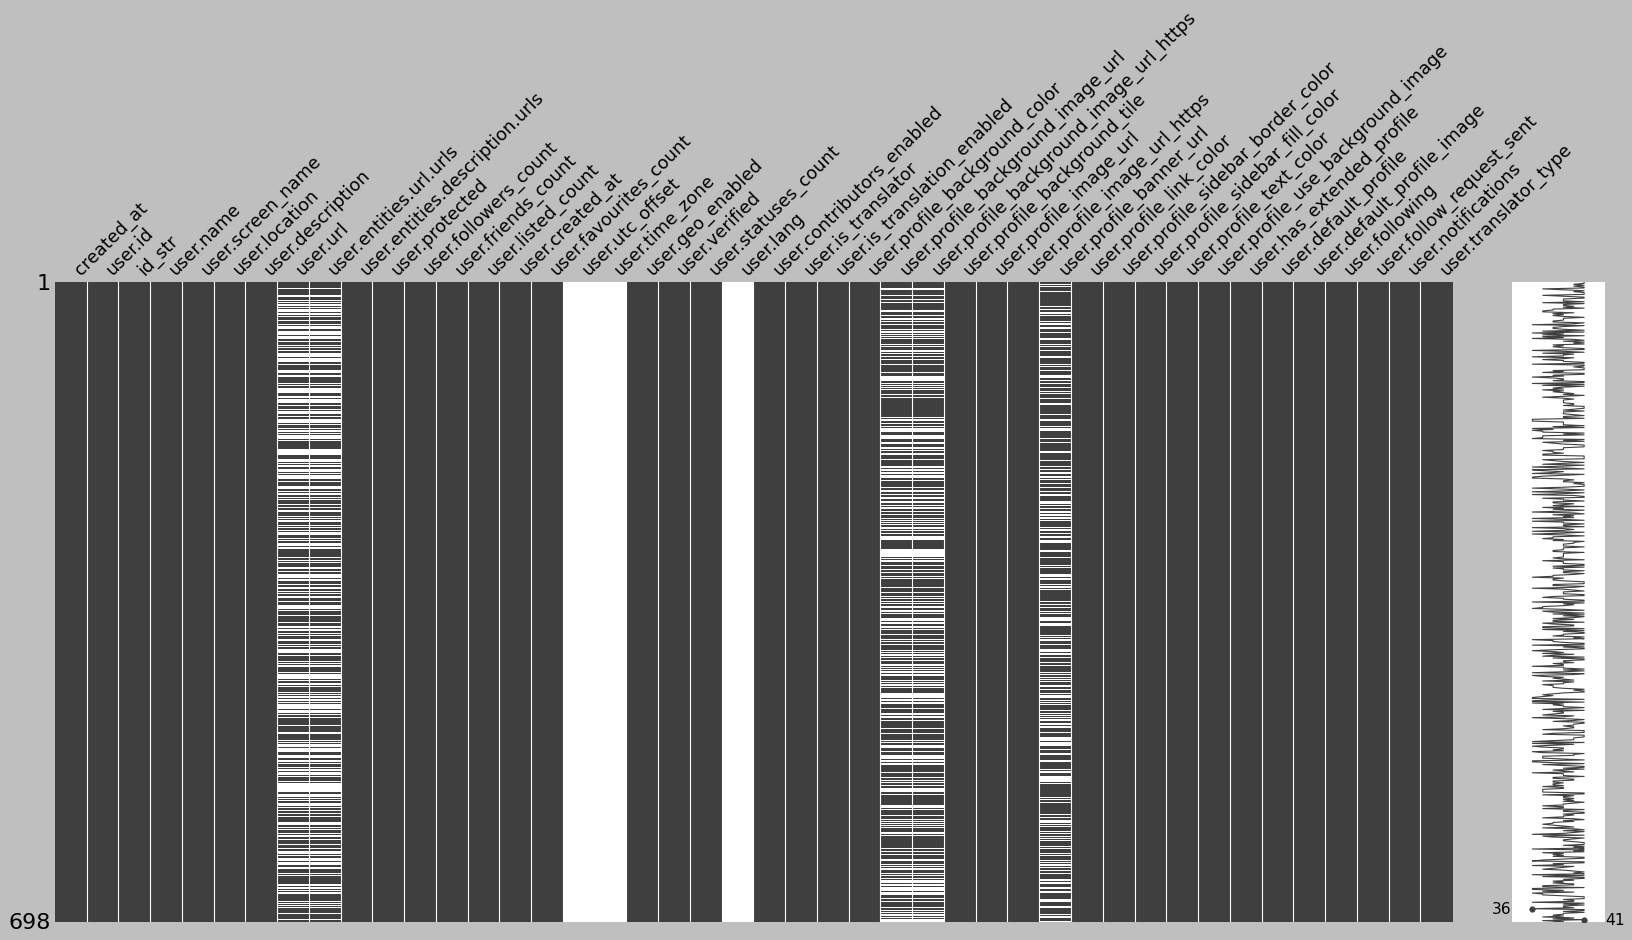

In [ ]:
msno.matrix(bots)

In [ ]:
bots = bots.rename(columns={'user.id_str': 'id_str'})
bots.id_str.value_counts()

,count
id_str,
971203153269018624,1
969398693249126400,1
2402022649,1
2976541239,1
4425828741,1
...,...
920359296797429760,1
1100190509073600513,1
4331829388,1


In [ ]:
bots = bots.rename(columns={'user.favourites_count': 'fave_count',
                            'user.followers_count': 'followers_count',
                            'user.friends_count': 'friends_count',
                            'user.verified': 'verified',
                            'user.name': 'name',
                            'user.screen_name': 'screen_name',
                            'user.location': 'location',
                            'user.description': 'description',
                            'user.default_profile':'default_prof'})
bots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   created_at                               698 non-null    object
 1   user.id                                  698 non-null    int64 
 2   id_str                                   698 non-null    object
 3   name                                     698 non-null    object
 4   screen_name                              698 non-null    object
 5   location                                 698 non-null    object
 6   description                              698 non-null    object
 7   user.url                                 382 non-null    object
 8   user.entities.url.urls                   382 non-null    object
 9   user.entities.description.urls           698 non-null    object
 10  user.protected                           698 non-null    bool 

In [ ]:
bots['val']= 'no'
bots['val'][0:3]

,val
0,no
1,no
2,no


In [ ]:
bots2= bots[['val','created_at', 'id_str', 'name', 'screen_name', 'location', 'description', 'verified', 'followers_count', 'friends_count', 'fave_count', 'default_prof']]

In [ ]:
bots2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 698 entries, 0 to 697
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   val              698 non-null    object
 1   created_at       698 non-null    object
 2   id_str           698 non-null    object
 3   name             698 non-null    object
 4   screen_name      698 non-null    object
 5   location         698 non-null    object
 6   description      698 non-null    object
 7   verified         698 non-null    bool  
 8   followers_count  698 non-null    int64 
 9   friends_count    698 non-null    int64 
 10  fave_count       698 non-null    int64 
 11  default_prof     698 non-null    bool  
dtypes: bool(2), int64(3), object(7)
memory usage: 56.0+ KB


##Interpretation
This bot dataset has 698 cases arranged in two columns: by date of creation and user. Json files are organized as distionaries and lists. In this case, the majority of the data is organized as subkeys under the parent key "user."

##Learning to use json

In [ ]:
bots.shape

(698, 2)

In [ ]:
bots.columns

Index(['created_at', 'user'], dtype='object')

In [ ]:
bots.dtypes

,0
created_at,"datetime64[ns, UTC]"
user,object


In [ ]:
for i in bots:
  print(i)

created_at
user


In [ ]:
keys= bots.keys()
print('DataFrame columns:', keys)
# If you want to see keys within the 'user' column's dictionaries:
# print('Keys in first user entry:', bots['user'][0].keys())

DataFrame columns: Index(['created_at', 'user'], dtype='object')


In [ ]:
def nested_keys(bots, parent_key=""):
    if isinstance(bots, dict):
        for key, value in bots.items():
            # Construct the path (e.g., location.city)
            full_key = f"{parent_key}.{key}" if parent_key else key

            if isinstance(value, (dict, list)):
                print(f"Key path: {full_key}")
                nested_keys(value, full_key)
            else:
                print(f"{full_key}: {value}")

    elif isinstance(bots, list):
        for index, item in enumerate(bots):
            nested_keys(item, f"{parent_key}[{index}]")

print(nested_keys(bots, "user"))

None


In [ ]:
#Stack Overflow: https://stackoverflow.com/questions/65716866/extracting-nested-json-keys-recursively
def nestk(bots,parents,n):
    for k, v in bots.items():
        if isinstance(v, dict):
            nestk(v,parents+" "+k, n+1)
        else:
            print(parents, k, v)

nestk(bots,"",0)

In [ ]:
print(bots["user"])

In [ ]:
print(bots['user'].str.get('id'))

In [ ]:
print(bots['user'][0:30].str.get('location'))

#Bot Data Exploration

<Axes: >

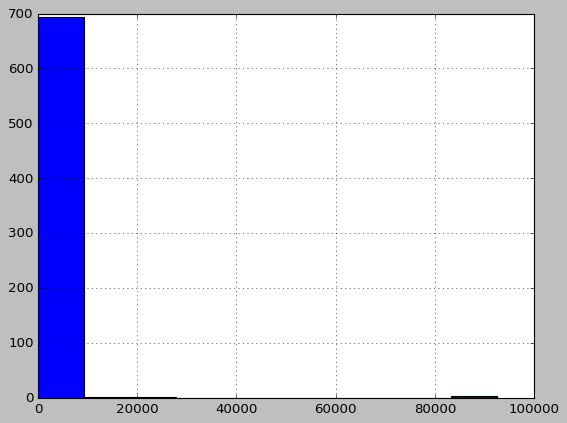

In [ ]:
bots['favourites_count'] = bots['user'].str.get('favourites_count')
bots["favourites_count"].hist()

<Axes: >

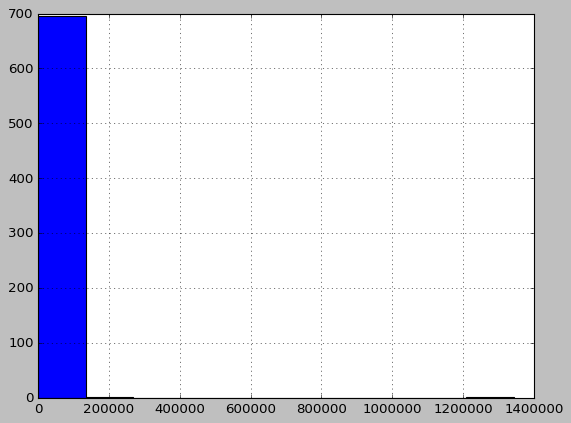

In [ ]:
bots['followers_count'] = bots['user'].str.get('followers_count')
bots['followers_count'].hist()

<Axes: xlabel='followers_count', ylabel='favourites_count'>

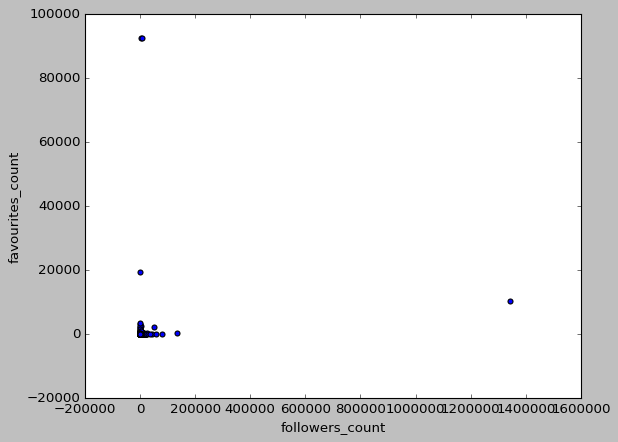

In [ ]:
bots.plot(kind='scatter', y='favourites_count', x='followers_count')

<Axes: >

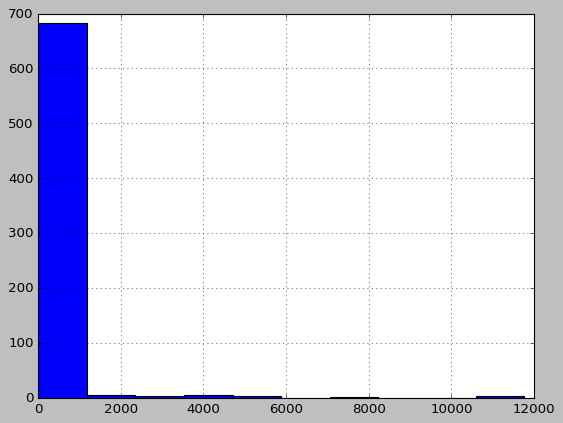

In [ ]:
bots['friends_count'] = bots['user'].str.get('friends_count')
bots['friends_count'].hist()

<Axes: xlabel='followers_count', ylabel='friends_count'>

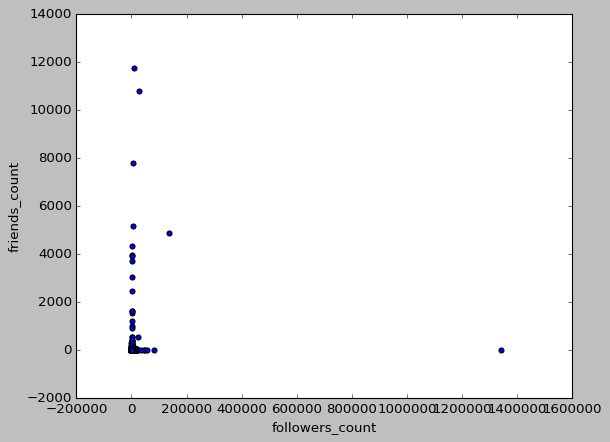

In [ ]:
bots.plot(kind='scatter', y='friends_count', x='followers_count')

In [ ]:
bots["favourites_count"].mean()
bots["favourites_count"].median()
bots["favourites_count"].max()

np.float64(362.58595988538684)

1.0

92588

In [ ]:
bots['followers_count'].mean()
bots['followers_count'].median()
bots['followers_count'].max()

np.float64(3511.8667621776503)

81.0

1342549

In [ ]:
bots['friends_count'].mean()
bots['friends_count'].median()
bots['friends_count'].max()

np.float64(115.46991404011462)

1.0

11762

##Interpretation
As expected from Yang et al.'s conclusions, the histograms for favourites count and followers counts show that most cases have low values within the possible range for these.
In the scatter plot, we can see that most counts appear to cap at 5,000. While both variables are similar in their low count, the data splits into a hyperbolic pattern with a) low followers; high favourites, b) high followers; low favourites. This suggests that bots are not engaging in many reciprocal connections, if at all.
When looking at the friends_count histogram, we see a similar overall low value for friends compared to the range, but the scatterplot between followers and friends supports the one-sided connectivity from the previous scatterplot.

#Human dataset

In [10]:
! wget -q -O verified-2019_tweets.json https://raw.githubusercontent.com/carlavilla/DataManagement/main/verified-2019_tweets.json
with open('verified-2019_tweets.json', 'r') as file:
    hooman_raw = json.load(file)

#hooman_raw= pd.read_json('verified-2019_tweets.json')
#hooman_raw.head(5)

In [11]:
hooman_raw[0]
hooman_raw[0]['user'] #['id']

hooman = pd.json_normalize(hooman_raw)
hooman.head(2)

{'created_at': 'Wed Jun 05 20:09:15 +0000 2019',
 'user': {'id': 31098240,
  'id_str': '31098240',
  'name': 'Netwerk24',
  'screen_name': 'Netwerk24',
  'location': 'Johannesburg',
  'description': 'Al die nuus, politiek, sport, geldsake & vermaak tot menings & diepteontledings, #AllesOpEenPlek & in Afrikaans! Volg @Netwerk24Sport vir top-sportnuus.',
  'url': 'https://t.co/Y0QuSqwwOL',
  'entities': {'url': {'urls': [{'url': 'https://t.co/Y0QuSqwwOL',
      'expanded_url': 'http://www.netwerk24.com',
      'display_url': 'netwerk24.com',
      'indices': [0, 23]}]},
   'description': {'urls': []}},
  'protected': False,
  'followers_count': 188419,
  'friends_count': 857,
  'listed_count': 432,
  'created_at': 'Tue Apr 14 10:57:46 +0000 2009',
  'favourites_count': 628,
  'utc_offset': None,
  'time_zone': None,
  'geo_enabled': False,
  'verified': True,
  'statuses_count': 117922,
  'lang': None,
  'contributors_enabled': False,
  'is_translator': False,
  'is_translation_enabled':

{'id': 31098240,
 'id_str': '31098240',
 'name': 'Netwerk24',
 'screen_name': 'Netwerk24',
 'location': 'Johannesburg',
 'description': 'Al die nuus, politiek, sport, geldsake & vermaak tot menings & diepteontledings, #AllesOpEenPlek & in Afrikaans! Volg @Netwerk24Sport vir top-sportnuus.',
 'url': 'https://t.co/Y0QuSqwwOL',
 'entities': {'url': {'urls': [{'url': 'https://t.co/Y0QuSqwwOL',
     'expanded_url': 'http://www.netwerk24.com',
     'display_url': 'netwerk24.com',
     'indices': [0, 23]}]},
  'description': {'urls': []}},
 'protected': False,
 'followers_count': 188419,
 'friends_count': 857,
 'listed_count': 432,
 'created_at': 'Tue Apr 14 10:57:46 +0000 2009',
 'favourites_count': 628,
 'utc_offset': None,
 'time_zone': None,
 'geo_enabled': False,
 'verified': True,
 'statuses_count': 117922,
 'lang': None,
 'contributors_enabled': False,
 'is_translator': False,
 'is_translation_enabled': False,
 'profile_background_color': '9AE4E8',
 'profile_background_image_url': 'htt

,created_at,user.id,user.id_str,user.name,user.screen_name,user.location,user.description,user.url,user.entities.url.urls,user.entities.description.urls,...,user.profile_sidebar_fill_color,user.profile_text_color,user.profile_use_background_image,user.has_extended_profile,user.default_profile,user.default_profile_image,user.following,user.follow_request_sent,user.notifications,user.translator_type
0,Wed Jun 05 20:09:15 +0000 2019,31098240,31098240,Netwerk24,Netwerk24,Johannesburg,"Al die nuus, politiek, sport, geldsake & verma...",https://t.co/Y0QuSqwwOL,"[{'url': 'https://t.co/Y0QuSqwwOL', 'expanded_...",[],...,DDFFCC,333333,False,False,False,False,False,False,False,none
1,Wed Jun 05 22:40:04 +0000 2019,6892002,6892002,WBIR Channel 10,wbir,"Knoxville, TN","News, Sports, Weather & Live At Five at 4:00 -...",None,NaN,[],...,B8D8F2,080808,True,False,False,False,False,False,False,none


In [12]:
hooman.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987 entries, 0 to 1986
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   created_at                               1987 non-null   object
 1   user.id                                  1987 non-null   int64 
 2   user.id_str                              1987 non-null   object
 3   user.name                                1987 non-null   object
 4   user.screen_name                         1987 non-null   object
 5   user.location                            1987 non-null   object
 6   user.description                         1987 non-null   object
 7   user.url                                 1670 non-null   object
 8   user.entities.url.urls                   1670 non-null   object
 9   user.entities.description.urls           1987 non-null   object
 10  user.protected                           1987 non-null   boo

In [ ]:
hooman.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Empty DataFrame


In [ ]:
hooman.describe()

,created_at,user
count,1987,1987
unique,NaN,1987
top,NaN,"{'id': 19084210, 'id_str': '19084210', 'name':..."
freq,NaN,1
mean,2019-06-04 02:12:36.485657088+00:00,NaN
min,2018-11-06 23:46:21+00:00,NaN
25%,2019-06-05 08:39:38.500000+00:00,NaN
50%,2019-06-05 19:32:19+00:00,NaN
75%,2019-06-05 22:23:04.500000+00:00,NaN
max,2019-06-06 01:14:09+00:00,NaN


<Axes: >

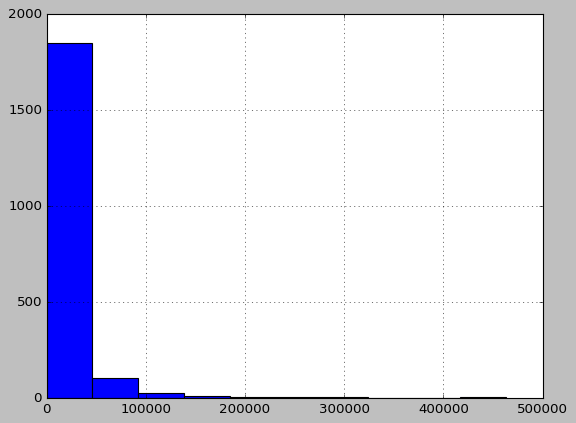

In [ ]:
hooman['favourites_count'] = hooman['user'].str.get('favourites_count')
hooman["favourites_count"].hist()

<Axes: >

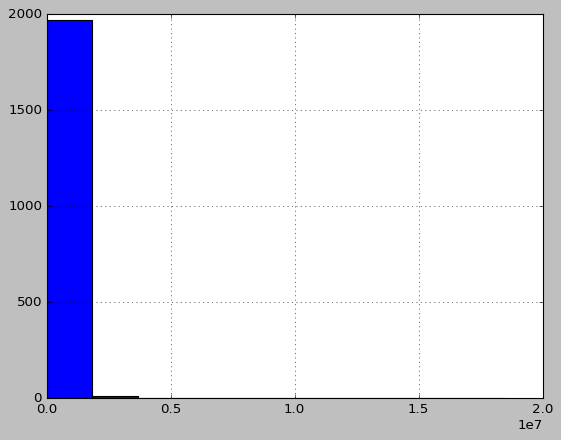

In [ ]:
hooman['followers_count'] = hooman['user'].str.get('followers_count')
hooman["followers_count"].hist()

<Axes: >

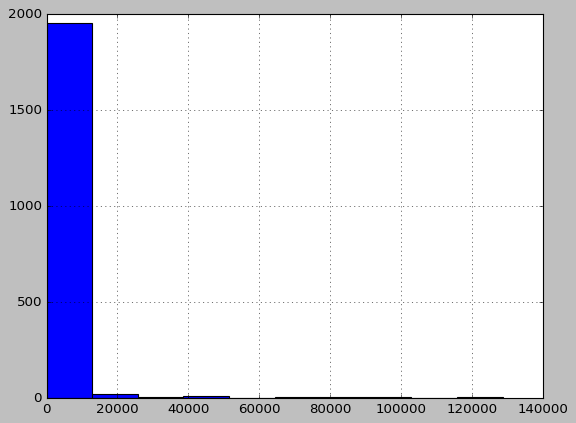

In [ ]:
hooman['friends_count'] = hooman['user'].str.get('friends_count')
hooman["friends_count"].hist()

<Axes: xlabel='followers_count', ylabel='favourites_count'>

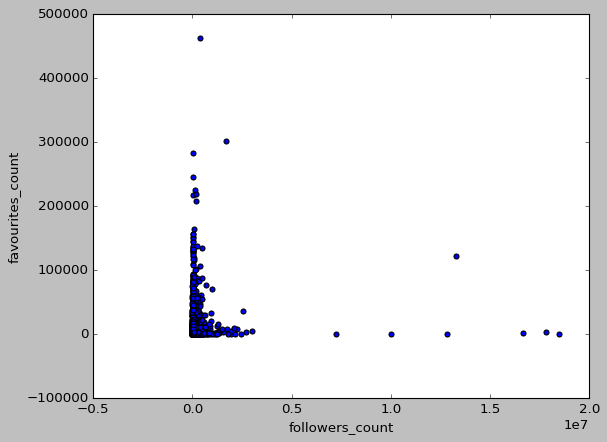

In [ ]:
hooman.plot(kind='scatter', y='favourites_count', x='followers_count')

<Axes: xlabel='followers_count', ylabel='friends_count'>

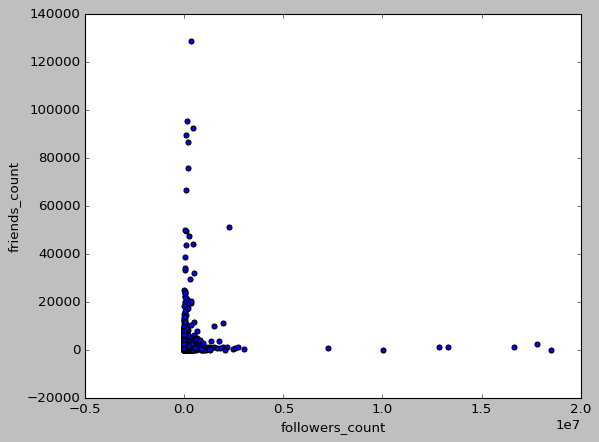

In [ ]:
hooman.plot(kind='scatter', y='friends_count', x='followers_count')

In [ ]:
hooman["favourites_count"].mean()
hooman["favourites_count"].median()
hooman["favourites_count"].max()

np.float64(14268.192249622547)

5494.0

462740

In [ ]:
hooman['followers_count'].mean()
hooman['followers_count'].median()
hooman['followers_count'].max()

np.float64(123033.92299949673)

11969.0

18489191

In [ ]:
hooman['friends_count'].mean()
hooman['friends_count'].median()
hooman['friends_count'].max()

np.float64(2526.140412682436)

1257.0

128736

In [ ]:
#Gemini created this for me. i take no credit.
import tabulate

favourites = [["Mean", hooman["favourites_count"].mean(), bots["favourites_count"].mean()],
        ["Median", hooman["favourites_count"].median(), bots["favourites_count"].median()],
        ["Max", hooman["favourites_count"].max(), bots["favourites_count"].max()],
        ["St.Dev.", hooman["favourites_count"].std(), bots["favourites_count"].std()]]
print(tabulate.tabulate(favourites, headers=["Metric Favorites", "Human", "Bot"])) # Added print here to display the first table

followers = [["Mean", hooman["followers_count"].mean(), bots["followers_count"].mean()],
        ["Median", hooman["followers_count"].median(), bots["followers_count"].median()],
        ["Max", hooman["followers_count"].max(), bots["followers_count"].max()]]
print(tabulate.tabulate(followers, headers=["Metric Followers", "Human", "Bot"]))

friends = [["Mean", hooman["friends_count"].mean(), bots["friends_count"].mean()],
        ["Median", hooman["friends_count"].median(), bots["friends_count"].median()],
        ["Max", hooman["friends_count"].max(), bots["friends_count"].max()]]
print(tabulate.tabulate(friends, headers=["Metric friends", "Human", "Bot"]))

<>:6: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
<>:6: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
/tmp/ipykernel_8334/374068347.py:6: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
  ["Max", hooman["favourites_count"].max(), bots["favourites_count"].max()]


NameError: name 'hooman' is not defined

##Interpretation
In line with Yang et al.'s model, the human counts for favorites and followers are much higher than the bots'. However, the friends count is also higher for humans. Furthermore, the companion scatterplots for humans show a similar pattern as that of bots- that is, low reciprocity of connections.

#Merged Datasets

In [ ]:
full= pd.concat([bots, hooman])
full.describe()

,favourites_count,faves_count,followers_count,friends_count
count,2685.000000,698.000000,2.685000e+03,2685.000000
mean,10653.252514,362.585960,9.196264e+04,1899.455866
std,24632.254498,5017.760445,7.540310e+05,5818.033281
min,0.000000,0.000000,0.000000e+00,0.000000
25%,59.000000,0.000000,1.402000e+03,63.000000
50%,2542.000000,1.000000,6.324000e+03,837.000000
75%,10257.000000,8.000000,2.472700e+04,1927.000000
max,462740.000000,92588.000000,1.848919e+07,128736.000000


<Axes: xlabel='followers_count', ylabel='favourites_count'>

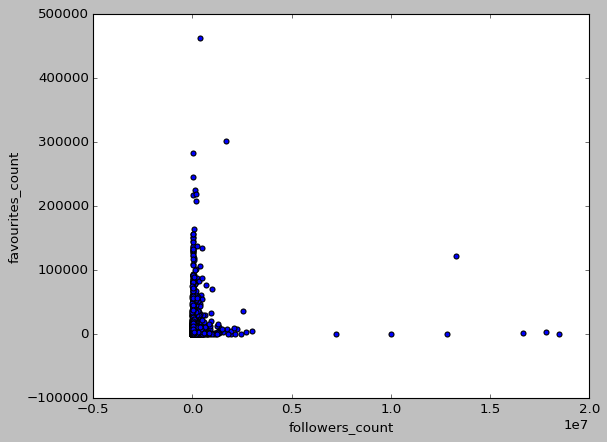

In [ ]:
full.plot(kind='scatter', y='favourites_count', x='followers_count')

<Axes: xlabel='followers_count', ylabel='friends_count'>

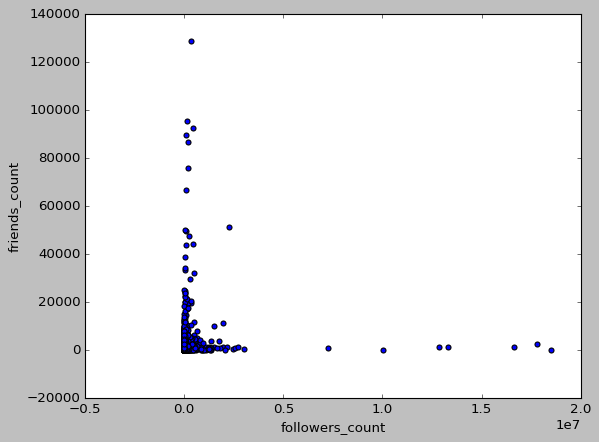

In [ ]:
full.plot(kind='scatter', y='friends_count', x='followers_count')

##Interpretation
This combined graph looks similar to those above, emphasizing the similarity in patterns for humans and bots.

#Next Steps:
Assign human and bot labels to data prior to merging so I can run a few more plots to compare these patterns.